# Predicción de Producción de Crudo y Análisis de Impacto Financiero

Este proyecto desarrolla un modelo de series temporales (SARIMAX) para predecir la producción mensual de petróleo crudo en Estados Unidos, utilizando el precio spot del WTI como variable exógena.
El objetivo principal no es solo minimizar el error estadístico, sino cuantificar la incertidumbre del modelo y traducir el error de pronóstico a impacto económico (USD), brindando herramientas directas para la toma de decisiones, planificación logística y cobertura de riesgos (hedging).

In [5]:
import os
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pmdarima as pm
from google.colab import userdata
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
'!pip install pmdarima'

# Configuración visual
plt.style.use('seaborn-v0_8-darkgrid')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 12.1 MB/s eta 0:00:00


## 1. Ingesta de Datos
Los datos se consumen directamente de la API pública de la Energy Information Administration (EIA). Se extraen dos series temporales desde el año 2000:
- Producción mensual de crudo en EE.UU. (miles de barriles diarios).
- Precio spot del petróleo WTI.

In [6]:
# Se recomienda configurar la API_KEY como variable de entorno local o en un archivo .env


API_KEY = userdata.get('EIA_API_KEY')

def fetch_eia_series(url, extra_facets, value_col, series_filter=None):
    params = {
        "api_key": API_KEY,
        "frequency": "monthly",
        "data[0]": "value",
        "start": "2000-01",
        "end": "2024-12",
        "sort[0][column]": "period",
        "sort[0][direction]": "asc",
        "offset": 0,
        "length": 5000
    }
    params.update(extra_facets)
    response = requests.get(url, params=params)
    response.raise_for_status()
    data = response.json()
    df_raw = pd.DataFrame(data["response"]["data"])

    if series_filter:
        df_raw = df_raw[df_raw['series'] == series_filter]

    df_raw["period"] = pd.to_datetime(df_raw["period"])
    df_raw = df_raw[["period", "value"]].rename(columns={"value": value_col})
    df_raw[value_col] = pd.to_numeric(df_raw[value_col])
    return df_raw.sort_values("period").set_index("period")

# Producción de crudo, US total
df_prod = fetch_eia_series(
    "https://api.eia.gov/v2/petroleum/crd/crpdn/data/",
    {"facets[duoarea][]": "NUS"},
    "production",
    series_filter='MCRFPUS1'
)

# Precio spot WTI (Cushing, OK) - serie RWTC
df_price = fetch_eia_series(
    "https://api.eia.gov/v2/petroleum/pri/spt/data/",
    {"facets[series][]": "RWTC"},
    "wti_price"
)

## 2. Limpieza y Consolidación
Unimos ambas series en un único DataFrame, asegurando la frecuencia mensual y manejando posibles valores faltantes mediante interpolación lineal.

In [7]:
df = df_prod.join(df_price, how="inner")
df = df.asfreq("MS")
df = df.interpolate()

print(df.tail())

            production  wti_price
period                           
2024-08-01      415726      76.68
2024-09-01      395118      70.24
2024-10-01      419427      71.99
2024-11-01      401875      69.95
2024-12-01      416555      70.12


## 3. Análisis Exploratorio de Datos (EDA)
Evaluamos la serie histórica y testeamos la estacionariedad mediante la prueba de Dickey-Fuller Aumentada (ADF). La estacionariedad es un requisito fundamental para modelos de la familia ARIMA.

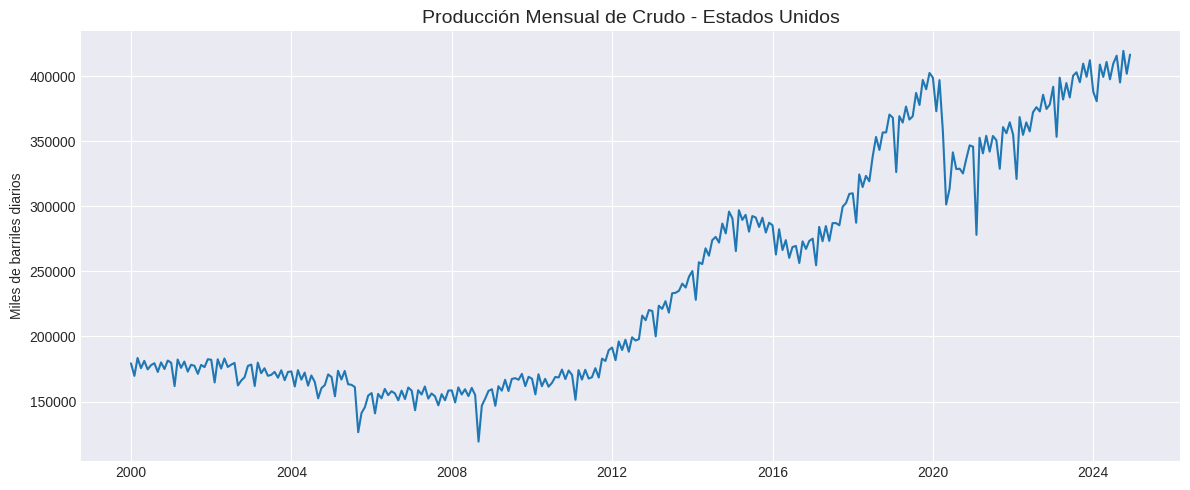

Prueba ADF (Serie Original):
ADF Statistic: 0.1483
p-value: 0.9692

Prueba ADF (Serie Diferenciada):
ADF Statistic: -3.7566
p-value: 0.0034



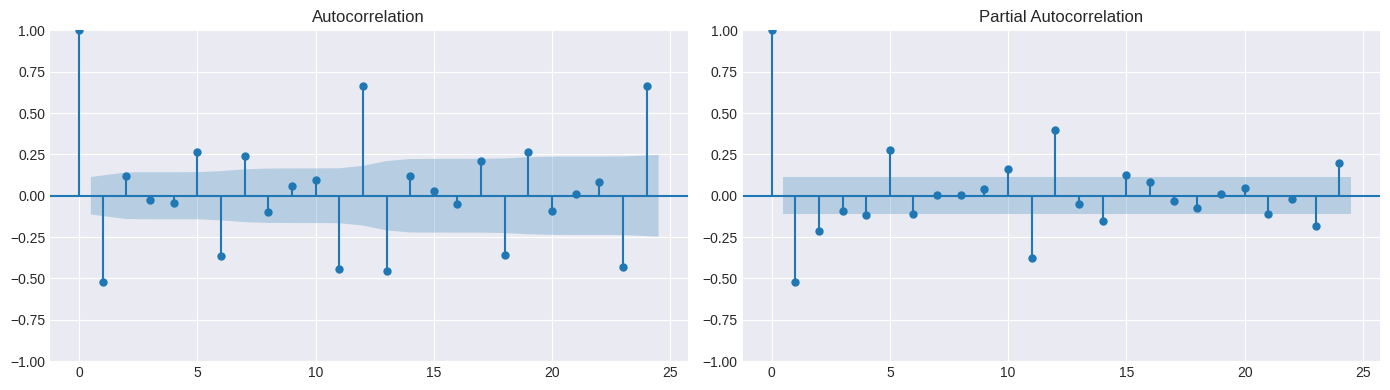

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["production"], color='#1f77b4')
plt.title("Producción Mensual de Crudo - Estados Unidos", fontsize=14)
plt.ylabel("Miles de barriles diarios")
plt.tight_layout()
plt.show()

# Test de estacionariedad (Dickey-Fuller Aumentado)
result = adfuller(df["production"].dropna())
print("Prueba ADF (Serie Original):")
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}\n")

# Diferenciación (d=1)
df["diff"] = df["production"].diff()

result_diff = adfuller(df["diff"].dropna())
print("Prueba ADF (Serie Diferenciada):")
print(f"ADF Statistic: {result_diff[0]:.4f}")
print(f"p-value: {result_diff[1]:.4f}\n")

# Gráficos ACF y PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df["diff"].dropna(), ax=axes[0], lags=24)
plot_pacf(df["diff"].dropna(), ax=axes[1], lags=24)
plt.tight_layout()
plt.show()

## 4. Modelado SARIMAX
Separamos los últimos 12 meses como conjunto de validación. Aplicamos una transformación logarítmica para estabilizar la varianza y ajustamos un modelo SARIMAX utilizando `auto_arima` para la optimización de hiperparámetros. El precio del WTI se incorpora como variable exógena.

In [9]:
train = df["production"].iloc[:-12]
test = df["production"].iloc[-12:]
exog_train = df[["wti_price"]].iloc[:-12]
exog_test = df[["wti_price"]].iloc[-12:]

train_log = np.log(train)

auto_model = pm.auto_arima(
    train_log,
    X=exog_train,
    seasonal=True,
    m=12,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True
)
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=-1090.257, Time=2.22 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=-785.809, Time=0.24 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=-985.631, Time=1.52 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=-950.539, Time=1.43 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=-787.129, Time=0.14 sec
 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=-945.243, Time=2.00 sec
 ARIMA(2,1,2)(1,0,0)[12] intercept   : AIC=-987.977, Time=3.71 sec
 ARIMA(2,1,2)(2,0,1)[12] intercept   : AIC=-1090.653, Time=9.87 sec
 ARIMA(2,1,2)(2,0,0)[12] intercept   : AIC=-1023.532, Time=9.70 sec
 ARIMA(2,1,2)(2,0,2)[12] intercept   : AIC=-1073.179, Time=6.08 sec
 ARIMA(2,1,2)(1,0,2)[12] intercept   : AIC=-1072.877, Time=8.10 sec
 ARIMA(1,1,2)(2,0,1)[12] intercept   : AIC=-1092.878, Time=4.12 sec
 ARIMA(1,1,2)(1,0,1)[12] intercept   : AIC=-1092.655, Time=2.16 sec
 ARIMA(1,1,2)(2,0,0)[12] intercept   : AIC=-1026.260, Time=6.46 sec
 ARIMA(1,1,

## 5. Validación y Métricas
Realizamos predicciones sobre el conjunto de test y revertimos la transformación logarítmica. Calculamos el RMSE y el MAPE para evaluar la precisión porcentual y absoluta del modelo.

RMSE: 11860.58 miles de barriles/día
MAPE: 2.39%


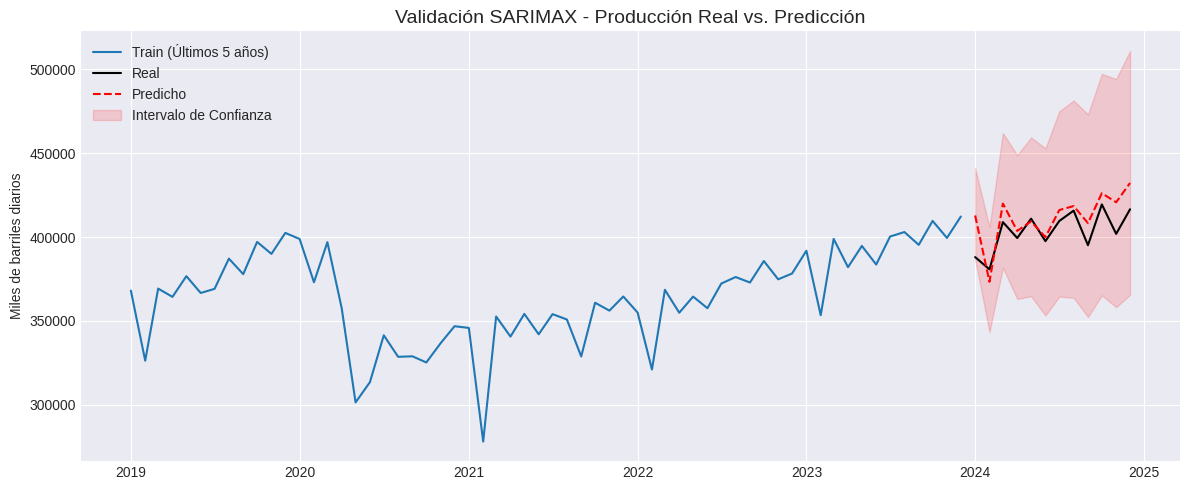

In [12]:
pred_log, conf_int_log = auto_model.predict(n_periods=12, X=exog_test, return_conf_int=True)

pred_mean = pd.Series(np.exp(pred_log), index=test.index)
conf_int = pd.DataFrame(np.exp(conf_int_log), index=test.index, columns=["lower", "upper"])

rmse = ((pred_mean.values - test.values) ** 2).mean() ** 0.5
mape = (abs((pred_mean.values - test.values) / test.values)).mean() * 100

print(f"RMSE: {rmse:.2f} miles de barriles/día")
print(f"MAPE: {mape:.2f}%")

plt.figure(figsize=(12, 5))
plt.plot(train.index[-60:], train.iloc[-60:], label="Train (Últimos 5 años)")
plt.plot(test.index, test, label="Real", color="black")
plt.plot(test.index, pred_mean, label="Predicho", linestyle="--", color="red")
plt.ylabel("Miles de barriles diarios")
plt.fill_between(test.index, conf_int["lower"], conf_int["upper"], color='red', alpha=0.15, label="Intervalo de Confianza")
plt.legend()
plt.title("Validación SARIMAX - Producción Real vs. Predicción", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Impacto de Negocio e Incertidumbre
El MAPE es útil a nivel técnico, pero carece de sentido comercial directo. En esta sección traducimos la diferencia de barriles/día al volumen total del mes y lo valorizamos según el precio del WTI de ese período. Esto cuantifica el riesgo financiero asociado a la desviación del pronóstico.

In [11]:
dias_por_mes = test.index.days_in_month
error_barriles_dia = (pred_mean - test)
error_barriles_totales = error_barriles_dia * 1000 * dias_por_mes
error_acumulado_barriles = error_barriles_totales.sum()

# Valorización del gap volumétrico
impacto_usd_mensual = error_barriles_totales * exog_test["wti_price"]
impacto_usd = impacto_usd_mensual.sum()

print("--- IMPACTO FINANCIERO DEL ERROR DE FORECAST ---")
print(f"Desvío volumétrico anual: {error_acumulado_barriles:,.0f} barriles")
print(f"Exposición financiera total: ${impacto_usd:,.0f} USD\n")
print("Interpretación:\nUn error en este forecast utilizado para planificación operativa implica un desvío en el flujo de caja operativo equivalente a la magnitud indicada. Valores positivos indican sobrestimación de ingresos esperados; negativos, subestimación.\n")

# Análisis de incertidumbre (amplitud del intervalo de confianza)
horizonte_meses = range(1, 13)
ancho_intervalo = (conf_int["upper"] - conf_int["lower"]).values
tabla_incertidumbre = pd.DataFrame({
    "Mes de Horizonte": list(horizonte_meses),
    "Amplitud Intervalo (Miles bbl/d)": ancho_intervalo
})
print("Evolución de la Incertidumbre (Riesgo a Largo Plazo):")
print(tabla_incertidumbre.to_string(index=False))

--- IMPACTO FINANCIERO DEL ERROR DE FORECAST ---
Desvío volumétrico anual: 2,986,781,446 barriles
Exposición financiera total: $220,210,177,684 USD

Interpretación:
Un error en este forecast utilizado para planificación operativa implica un desvío en el flujo de caja operativo equivalente a la magnitud indicada. Valores positivos indican sobrestimación de ingresos esperados; negativos, subestimación.

Evolución de la Incertidumbre (Riesgo a Largo Plazo):
 Mes de Horizonte  Amplitud Intervalo (Miles bbl/d)
                1                      54671.571893
                2                      62606.609926
                3                      80303.582903
                4                      85651.389223
                5                      94668.264585
                6                      99565.457363
                7                     110452.950125
                8                     117597.640407
                9                     120766.433539
               10    